0 - Negative

1 - Positive

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud as wc
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer as cv

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kshitij\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df1 = pd.read_csv(r'../Dataset/pos_label.csv',encoding='latin-1')
df2 = pd.read_csv(r'../Dataset/neg_label.csv',encoding='latin-1')
df = pd.concat([df1,df2], ignore_index=True)
# df =df3

In [5]:
df.shape

(1638475, 2)

In [6]:
df.sample(7)

,Label,Comment
1243582,0,Lesson of the day: don't start packing a coupl...
185167,1,@kestra I am good tah Glad 2 hear things are ...
163598,1,Yes it's almost one and we are just waking up....
669689,1,is not quite sure what to do Rejoice as i am ...
1273282,0,@francesxo FRANCESSSS!!My internet cut off!She...
682985,1,@Airbase that sounds yum! I'm in the other han...
1232506,0,"@marpizza I sense evasion. Seriously, are you..."


In [7]:
df.isnull().sum()


Label      0
Comment    0
dtype: int64

<Axes: ylabel='Frequency'>

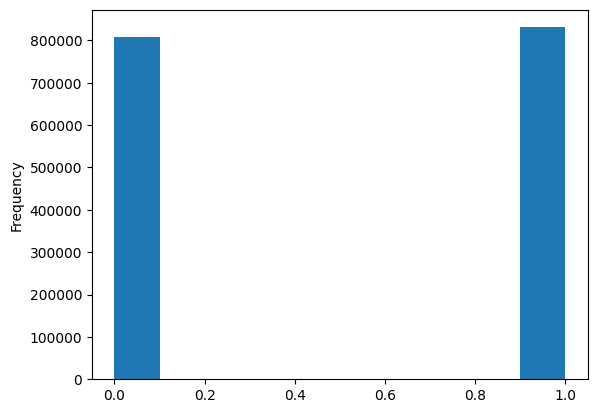

In [8]:
df['Label'].plot(bins=10, kind='hist')

In [9]:
negative_tweets = df[df['Label']==0]
negative_tweets.iloc[:3]

,Label,Comment
830900,0,is upset that he can't update his Facebook by ...
830901,0,@Kenichan I dived many times for the ball. Man...
830902,0,my whole body feels itchy and like its on fire


In [10]:
positive_tweets = df[df['Label']==1]
positive_tweets.iloc[:3]

,Label,Comment
0,1,I LOVE @Health1UandPets u guys r the best!!
1,1,im meeting up with one of my besties tonight! ...
2,1,"@DaRealSunisaKim Thanks for the Twitter add, S..."


In [14]:
pos_list = positive_tweets['Comment'].tolist()
pos_list[:3]

['I LOVE @Health1UandPets u guys r the best!! ',
 'im meeting up with one of my besties tonight! Cant wait!!  - GIRL TALK!!',
 '@DaRealSunisaKim Thanks for the Twitter add, Sunisa! I got to meet you once at a HIN show here in the DC area and you were a sweetheart. ']

In [15]:
pos_string = " ".join(pos_list)
len(pos_string)

64154530

In [17]:
neg_list = negative_tweets['Comment'].tolist()
neg_list[:3]

["is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
 '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
 'my whole body feels itchy and like its on fire ']

In [18]:
neg_string = " ".join(neg_list)
len(neg_string)

62135358

In [19]:
#remove punctuation
punctuation_ = string.punctuation + '1234567890Â©á»áº¯ÄÃ'+ '¢`~¡¢£¤¥¦§¨©ª«¬®¯°±²³´µ¶·¸¹º»¼½¾¿×÷¢£¤¥¦§©´µ¶·¸¹º€£¥₹₽₿₣₱₩₨₫₮₭₣₢₥₦₠₡₧₤₮₯₰₲₱₴₵₸₹₺₻₼₽₿'
punctuation_

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~1234567890Â©á»áº¯ÄÃ¢`~¡¢£¤¥¦§¨©ª«¬®¯°±²³´µ¶·¸¹º»¼½¾¿×÷¢£¤¥¦§©´µ¶·¸¹º€£¥₹₽₿₣₱₩₨₫₮₭₣₢₥₦₠₡₧₤₮₯₰₲₱₴₵₸₹₺₻₼₽₿'

In [20]:
pos_list=[ch for ch in pos_string if ch not in punctuation_]
pos_string = ''.join(pos_list)
len(pos_string)

60012429

In [21]:
neg_list=[ch for ch in neg_string if ch not in punctuation_]
neg_string = ''.join(neg_list)
len(neg_string)

58506198

In [24]:
#remove stopwords
stopw = stopwords.words('english')
stopw.extend(list(string.ascii_lowercase))
stopw.extend(['0','1','2','3','4','5','6','7','8','9','https','www','com'])
stopw[:5]

['i', 'me', 'my', 'myself', 'we']

In [25]:
pos_list = [word for word in pos_string.split() if word.lower() not in stopw]
pos_string = " ".join(pos_list)
len(pos_string)

42864342

In [31]:
pos_string[:40]

'LOVE HealthUandPets guys best im meeting'

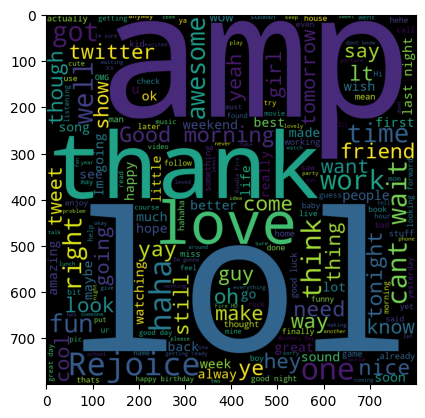

In [27]:
wordcloud = wc(width=800, height=800, background_color='black').generate(pos_string)
plt.imshow(wordcloud)

In [28]:
neg_list = [word for word in neg_string.split() if word.lower() not in stopw]
neg_string = ' '.join(neg_list)
len(neg_string)

40587504

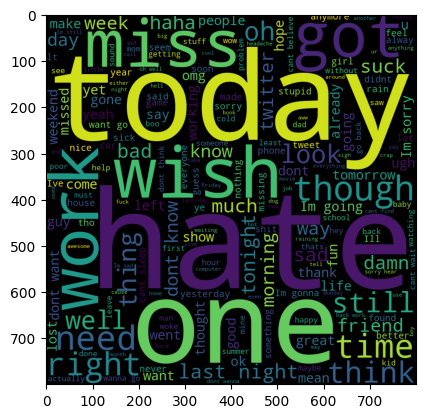

In [29]:
wordcloud = wc(width=800, height=800, background_color='black').generate(neg_string)
plt.imshow(wordcloud)